# Huấn Luyện Fusion Model (EfficientNetV2-S + ResNet50) với On-The-Fly ROI

Notebook này là sự kết hợp mạnh mẽ giữa 2 kỹ thuật:
1. **On-the-fly ROI Extraction:** Đọc file label `.txt` (YOLO Format) từ tập dataset xuất bởi Roboflow và tự động cắt vùng có con bọ (ROI) đưa vào mô hình.
2. **Advanced Fusion Architecture:** Sử dụng kiến trúc lai ghép `EfficientNetV2-S + ResNet50` kết hợp chiến lược huấn luyện 2 Giai Đoạn (Frozen Head -> Fine-Tuning) tích hợp Early Stopping.

In [ ]:
import os
import re
import time
import copy
import random
import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

# ==========================================
# CẤU HÌNH THÔNG SỐ (CONFIG)
# ==========================================
DATASET_ROOT = "/kaggle/input/datasets/hadesoverflow/crop-pests-dataset"

TRAIN_DIR = os.path.join(DATASET_ROOT, "train")
VALID_DIR = os.path.join(DATASET_ROOT, "valid")
TEST_DIR  = os.path.join(DATASET_ROOT, "test")

OUT_DIR = "/kaggle/working/fusion_pest_weights"
os.makedirs(OUT_DIR, exist_ok=True)

BATCH_SIZE     = 16   # Fusion model rất lớn, dùng 16 để tránh tràn VRAM
EPOCHS_PHASE_1 = 15
EPOCHS_PHASE_2 = 10
LR_HEAD        = 1e-3
IMG_SIZE       = 288
SEED           = 42

# Tự động đọc tên class từ data.yaml (không cần cài thêm thư viện)
YAML_PATH   = os.path.join(DATASET_ROOT, "data.yaml")
CLASS_NAMES = []
if os.path.exists(YAML_PATH):
    with open(YAML_PATH, 'r') as f:
        content = f.read()
    CLASS_NAMES = re.findall(r'\"([^\"]+)\"', content)

NUM_CLASSES = len(CLASS_NAMES) if CLASS_NAMES else 12
print(f"Số class    : {NUM_CLASSES}")
print(f"Tên classes : {CLASS_NAMES}")

def set_seed(seed=42):
    random.seed(seed);  np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

set_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Thiết bị: {device}")

Số class    : 12
Tên classes : ['Ants', 'Bees', 'Beetles', 'Caterpillars', 'Earthworms', 'Earwigs', 'Grasshoppers', 'Moths', 'Slugs', 'Snails', 'Wasps', 'Weevils']
Thiết bị: cuda


## 1. PyTorch Dataset: Tự động Đọc `.txt` và Cắt Ảnh

In [10]:
class PestROIDataset(Dataset):
    def __init__(self, split_dir, transform=None):
        self.split_dir  = split_dir
        self.transform  = transform
        self.images_dir = os.path.join(split_dir, "images")
        self.labels_dir = os.path.join(split_dir, "labels")
        self.image_files = []
        if os.path.exists(self.images_dir):
            self.image_files = [f for f in os.listdir(self.images_dir)
                                if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    def __len__(self): return len(self.image_files)

    def read_yolo_bboxes(self, txt_path):
        bboxes = []
        if not os.path.exists(txt_path): return bboxes
        with open(txt_path, 'r') as f:
            for line in f:
                data = line.strip().split()
                if len(data) >= 5:
                    c_id = int(data[0])
                    cx, cy, w, h = map(float, data[1:5])
                    bboxes.append({'class_id': c_id, 'cx': cx, 'cy': cy, 'w': w, 'h': h})
        return bboxes

    def _crop_roi(self, img, bbox):
        """Chuyển đổi tọa độ YOLO chuẩn hóa sang pixel và cắt ROI."""
        img_h, img_w = img.shape[:2]
        cx_px = int(bbox['cx'] * img_w)
        cy_px = int(bbox['cy'] * img_h)
        w_px  = int(bbox['w']  * img_w)
        h_px  = int(bbox['h']  * img_h)
        x1 = max(0, cx_px - w_px // 2)
        y1 = max(0, cy_px - h_px // 2)
        x2 = min(img_w, cx_px + w_px // 2)
        y2 = min(img_h, cy_px + h_px // 2)
        roi = img[y1:y2, x1:x2]
        return roi if roi.size > 0 else img

    def __getitem__(self, idx):
        # FIX: Vòng lặp bỏ qua ảnh lỗi thay vì crash toàn bộ DataLoader
        while True:
            try:
                img_name = self.image_files[idx]
                img_path = os.path.join(self.images_dir, img_name)
                txt_path = os.path.join(self.labels_dir, os.path.splitext(img_name)[0] + ".txt")

                img = cv2.imread(img_path)
                if img is None: raise IOError(f"Không đọc được ảnh: {img_path}")

                bboxes = self.read_yolo_bboxes(txt_path)

                if bboxes:
                    # Ưu tiên cắt con bọ có diện tích BBox lớn nhất
                    largest = max(bboxes, key=lambda b: b['w'] * b['h'])
                    class_id = largest['class_id']
                    roi = self._crop_roi(img, largest)
                else:
                    roi      = img
                    class_id = 0

                roi     = cv2.resize(roi, (IMG_SIZE, IMG_SIZE))
                roi_rgb = cv2.cvtColor(roi, cv2.COLOR_BGR2RGB)
                pil_img = Image.fromarray(roi_rgb)
                img_tensor = self.transform(pil_img) if self.transform else transforms.ToTensor()(pil_img)
                return img_tensor, torch.tensor(class_id, dtype=torch.long)

            except Exception:
                idx = random.randint(0, len(self.image_files) - 1)

# Transforms
train_tf = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

try:
    train_ds = PestROIDataset(TRAIN_DIR, transform=train_tf)
    val_ds   = PestROIDataset(VALID_DIR, transform=val_tf)
    print(f"Train: {len(train_ds)} ảnh | Val: {len(val_ds)} ảnh")
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
except Exception as e:
    print("Lỗi Dataset:", e)

Train: 11502 ảnh | Val: 1095 ảnh


## 1.5. Kiểm Tra Trực Quan ROI (CHẠY TRƯỚC KHI TRAIN!)

Cell này hiển thị song song **Ảnh gốc** (có khung BBox màu xanh) và **Ảnh ROI đã cắt & resize**.

Nếu cột phải hiển thị đúng phần thân con bọ (không phải nền lá cây), pipeline đang hoạt động đúng!

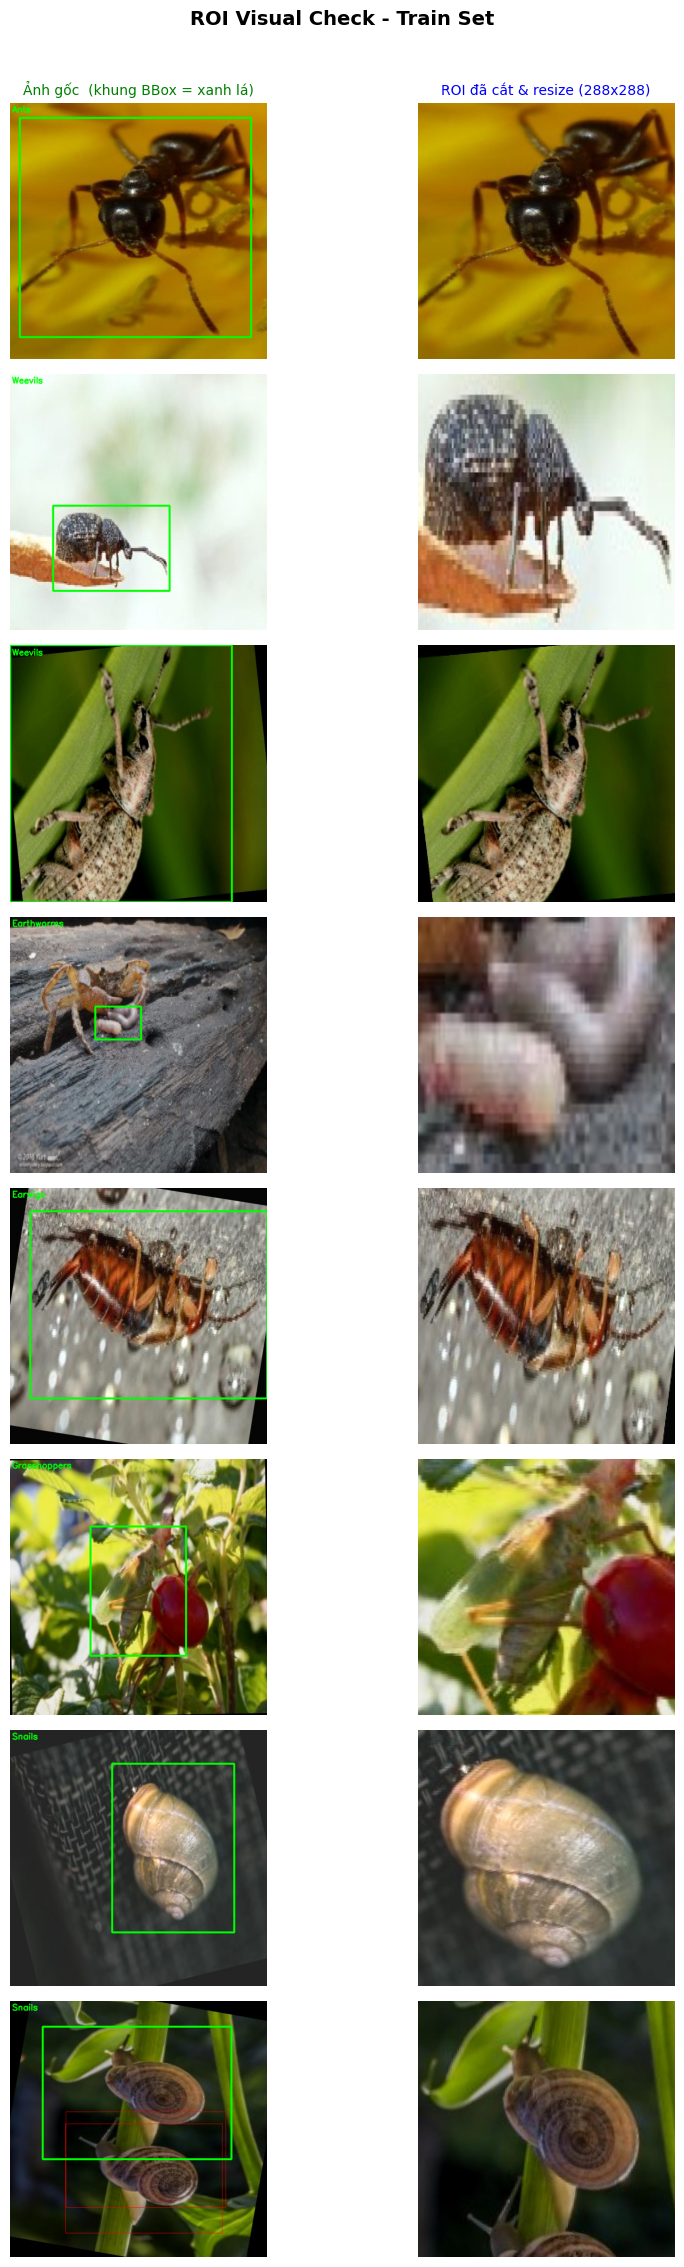

✅ Đã lưu ảnh kiểm tra tại: /kaggle/working/fusion_pest_weights/roi_visual_check.png


In [11]:
def visualize_roi_check(split_dir, class_names, n_samples=8, title="ROI Visual Check"):
    images_dir = os.path.join(split_dir, "images")
    labels_dir = os.path.join(split_dir, "labels")
    if not os.path.exists(images_dir):
        print(f"Không tìm thấy: {images_dir}"); return

    all_files = [f for f in os.listdir(images_dir) if f.lower().endswith(('.jpg','.jpeg','.png'))]
    samples   = random.sample(all_files, min(n_samples, len(all_files)))
    helper    = PestROIDataset(split_dir, transform=None)

    fig, axes = plt.subplots(n_samples, 2, figsize=(10, n_samples * 2.8))
    if n_samples == 1: axes = axes[np.newaxis, :]
    fig.suptitle(title, fontsize=14, fontweight='bold', y=1.01)
    axes[0, 0].set_title("Ảnh gốc  (khung BBox = xanh lá)", fontsize=10, color='green')
    axes[0, 1].set_title(f"ROI đã cắt & resize ({IMG_SIZE}x{IMG_SIZE})", fontsize=10, color='blue')

    for row, img_name in enumerate(samples):
        img_path = os.path.join(images_dir, img_name)
        txt_path = os.path.join(labels_dir, os.path.splitext(img_name)[0] + ".txt")
        img = cv2.imread(img_path)
        if img is None:
            axes[row, 0].set_visible(False); axes[row, 1].set_visible(False); continue

        img_h, img_w = img.shape[:2]
        bboxes  = helper.read_yolo_bboxes(txt_path)
        vis_img = img.copy()
        roi     = img.copy()
        cls_name = "no_label"

        if bboxes:
            largest  = max(bboxes, key=lambda b: b['w'] * b['h'])
            c_id     = largest['class_id']
            cls_name = class_names[c_id] if class_names and c_id < len(class_names) else str(c_id)
            roi      = helper._crop_roi(img, largest)

            # Vẽ tất cả BBox (xanh lá = con được chọn, đỏ = con còn lại)
            for bb in bboxes:
                color = (0, 255, 0) if bb is largest else (0, 0, 255)
                thick = 3           if bb is largest else 1
                cx_px = int(bb['cx'] * img_w); cy_px = int(bb['cy'] * img_h)
                w_px  = int(bb['w']  * img_w); h_px  = int(bb['h']  * img_h)
                x1 = max(0, cx_px - w_px // 2); y1 = max(0, cy_px - h_px // 2)
                x2 = min(img_w, cx_px + w_px // 2); y2 = min(img_h, cy_px + h_px // 2)
                cv2.rectangle(vis_img, (x1, y1), (x2, y2), color, thick)
            cv2.putText(vis_img, cls_name, (5, 25), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0,255,0), 2)

        # Cột trái: Ảnh gốc có khung
        axes[row, 0].imshow(cv2.cvtColor(vis_img, cv2.COLOR_BGR2RGB))
        axes[row, 0].set_ylabel(cls_name, fontsize=9, rotation=0, labelpad=65, va='center')
        axes[row, 0].axis('off')

        # Cột phải: ROI đã cắt và phóng to
        axes[row, 1].imshow(cv2.cvtColor(cv2.resize(roi, (IMG_SIZE, IMG_SIZE)), cv2.COLOR_BGR2RGB))
        axes[row, 1].axis('off')

    plt.tight_layout()
    save_path = os.path.join(OUT_DIR, 'roi_visual_check.png')
    plt.savefig(save_path, bbox_inches='tight', dpi=100)
    plt.show()
    print(f"✅ Đã lưu ảnh kiểm tra tại: {save_path}")

# Kiểm tra 8 mẫu ngẫu nhiên từ tập Train
visualize_roi_check(TRAIN_DIR, CLASS_NAMES, n_samples=8, title="ROI Visual Check - Train Set")

## 2. Kiến Trúc Fusion Model (EfficientNetV2-S + ResNet50)
Head được thiết kế dạng phễu: `concat(3328) -> 1024 -> 256 -> num_classes`

In [12]:
def freeze_batchnorm_layers(module):
    for m in module.modules():
        if isinstance(m, nn.BatchNorm2d):
            m.eval()
            if m.weight is not None: m.weight.requires_grad = False
            if m.bias   is not None: m.bias.requires_grad   = False

def set_batchnorm_eval(module):
    for m in module.modules():
        if isinstance(m, nn.BatchNorm2d): m.eval()

class EfficientResNetFusion(nn.Module):
    def __init__(self, num_classes, dropout=0.4):
        super().__init__()
        eff_net = models.efficientnet_v2_s(weights=models.EfficientNet_V2_S_Weights.DEFAULT)
        self.eff_features = eff_net.features
        self.eff_pool     = nn.AdaptiveAvgPool2d((1, 1))
        eff_dim = 1280

        resnet = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        self.res_features = nn.Sequential(
            resnet.conv1, resnet.bn1, resnet.relu, resnet.maxpool,
            resnet.layer1, resnet.layer2, resnet.layer3, resnet.layer4
        )
        self.res_pool = nn.AdaptiveAvgPool2d((1, 1))
        res_dim = 2048

        # Classifier Head dạng phễu: 3328 -> 1024 -> 256 -> N classes
        self.classifier = nn.Sequential(
            nn.Linear(eff_dim + res_dim, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),

            nn.Linear(1024, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout / 2),

            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        feat_e = torch.flatten(self.eff_pool(self.eff_features(x)), 1)
        feat_r = torch.flatten(self.res_pool(self.res_features(x)), 1)
        return self.classifier(torch.cat([feat_e, feat_r], dim=1))

model_fusion = EfficientResNetFusion(NUM_CLASSES).to(device)
total_p    = sum(p.numel() for p in model_fusion.parameters())
train_p    = sum(p.numel() for p in model_fusion.parameters() if p.requires_grad)
print(f"Tổng tham số  : {total_p:,}")
print(f"Có thể train  : {train_p:,}")

Tổng tham số  : 47,362,460
Có thể train  : 47,362,460


## 3. Các Hàm Huấn Luyện & Early Stopping

In [17]:
def train_model(model, name, config_lr, epochs_limit, freeze_backbones=True, early_stop_patience=5):
    if freeze_backbones:
        for p in model.eff_features.parameters(): p.requires_grad = False
        for p in model.res_features.parameters(): p.requires_grad = False
        freeze_batchnorm_layers(model.eff_features)
        freeze_batchnorm_layers(model.res_features)
    else:
        for p in model.parameters(): p.requires_grad = True

    head_params     = [p for n, p in model.named_parameters() if 'classifier' in n and p.requires_grad]
    backbone_params = [p for n, p in model.named_parameters() if 'classifier' not in n and p.requires_grad]

    param_groups = []
    if backbone_params: param_groups.append({'params': backbone_params, 'lr': config_lr.get('backbone', 1e-5)})
    if head_params:     param_groups.append({'params': head_params,     'lr': config_lr.get('head', 1e-3)})

    optimizer  = optim.AdamW(param_groups, weight_decay=1e-4)
    criterion  = nn.CrossEntropyLoss()
    scheduler  = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

    history       = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_acc      = 0.0
    best_val_loss = float('inf')
    best_weights  = copy.deepcopy(model.state_dict())
    es_counter    = 0

    print(f"\n🚀 Bắt đầu Train: {name}")
    for epoch in range(epochs_limit):
        start = time.time()

        # --- TRAIN ---
        model.train()
        if freeze_backbones:
            set_batchnorm_eval(model.eff_features)
            set_batchnorm_eval(model.res_features)

        t_loss, t_correct, t_total = 0.0, 0, 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            out  = model(imgs)
            loss = criterion(out, labels)
            loss.backward(); optimizer.step()
            t_loss    += loss.item() * imgs.size(0)
            t_correct += (out.argmax(1) == labels).sum().item()
            t_total   += imgs.size(0)

        # --- VAL ---
        model.eval()
        v_loss, v_correct, v_total = 0.0, 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                out  = model(imgs)
                loss = criterion(out, labels)
                v_loss    += loss.item() * imgs.size(0)
                v_correct += (out.argmax(1) == labels).sum().item()
                v_total   += imgs.size(0)

        t_loss, t_acc = t_loss / t_total, t_correct / t_total
        v_loss, v_acc = v_loss / v_total, v_correct / v_total
        history['train_loss'].append(t_loss); history['train_acc'].append(t_acc)
        history['val_loss'].append(v_loss);   history['val_acc'].append(v_acc)

        scheduler.step(v_loss)
        print(f"Epoch [{epoch+1:02d}/{epochs_limit}] | Train: Loss={t_loss:.4f} Acc={t_acc:.4f} | Val: Loss={v_loss:.4f} Acc={v_acc:.4f} | {time.time()-start:.1f}s")

        if v_acc > best_acc:
            best_acc     = v_acc
            best_weights = copy.deepcopy(model.state_dict())
            torch.save(model.state_dict(), os.path.join(OUT_DIR, f'best_{name}.pth'))
            print(f"  ✅ Lưu best model! Val Acc = {best_acc:.4f}")

        if v_loss < best_val_loss:
            best_val_loss = v_loss; es_counter = 0
        else:
            es_counter += 1
            print(f"  [ES] Không cải thiện {es_counter}/{early_stop_patience}")
            if es_counter >= early_stop_patience:
                print(f"  ⏹ Early Stopping tại epoch {epoch+1}!"); break

    model.load_state_dict(best_weights)
    return model, best_acc, history

## 4. Thực Thi Quá Trình Học 2 Giai Đoạn

In [18]:
print("\n===== PHASE 1: TRAINING HEAD (BACKBONES FROZEN) =====")
model_fusion, acc_p1, hist_p1 = train_model(
    model_fusion, name='Fusion_Pest_Phase1',
    config_lr={'head': LR_HEAD},
    epochs_limit=EPOCHS_PHASE_1, freeze_backbones=True, early_stop_patience=5
)

print("\n===== PHASE 2: UNFREEZE & FINE-TUNING =====")
model_fusion, acc_p2, hist_p2 = train_model(
    model_fusion, name='Fusion_Pest_Final',
    config_lr={'backbone': 1e-5, 'head': 1e-4},
    epochs_limit=EPOCHS_PHASE_2, freeze_backbones=False, early_stop_patience=4
)


===== PHASE 1: TRAINING HEAD (BACKBONES FROZEN) =====

🚀 Bắt đầu Train: Fusion_Pest_Phase1
Epoch [01/15] | Train: Loss=0.3201 Acc=0.9066 | Val: Loss=0.2031 Acc=0.9425 | 146.6s
  ✅ Lưu best model! Val Acc = 0.9425
Epoch [02/15] | Train: Loss=0.1742 Acc=0.9472 | Val: Loss=0.2156 Acc=0.9379 | 145.1s
  [ES] Không cải thiện 1/5
Epoch [03/15] | Train: Loss=0.1323 Acc=0.9591 | Val: Loss=0.1937 Acc=0.9470 | 144.3s
  ✅ Lưu best model! Val Acc = 0.9470
Epoch [04/15] | Train: Loss=0.1092 Acc=0.9666 | Val: Loss=0.2256 Acc=0.9470 | 144.0s
  [ES] Không cải thiện 1/5
Epoch [05/15] | Train: Loss=0.0960 Acc=0.9689 | Val: Loss=0.2366 Acc=0.9489 | 145.0s
  ✅ Lưu best model! Val Acc = 0.9489
  [ES] Không cải thiện 2/5
Epoch [06/15] | Train: Loss=0.0790 Acc=0.9750 | Val: Loss=0.2048 Acc=0.9479 | 144.8s
  [ES] Không cải thiện 3/5
Epoch [07/15] | Train: Loss=0.0524 Acc=0.9836 | Val: Loss=0.2032 Acc=0.9534 | 144.0s
  ✅ Lưu best model! Val Acc = 0.9534
  [ES] Không cải thiện 4/5
Epoch [08/15] | Train: Loss=0.

## 5. Trực Quan Hóa Kết Quả


TỔNG KẾT
  Phase 1 Best Val Acc: 95.34%
  Phase 2 Best Val Acc: 95.43%


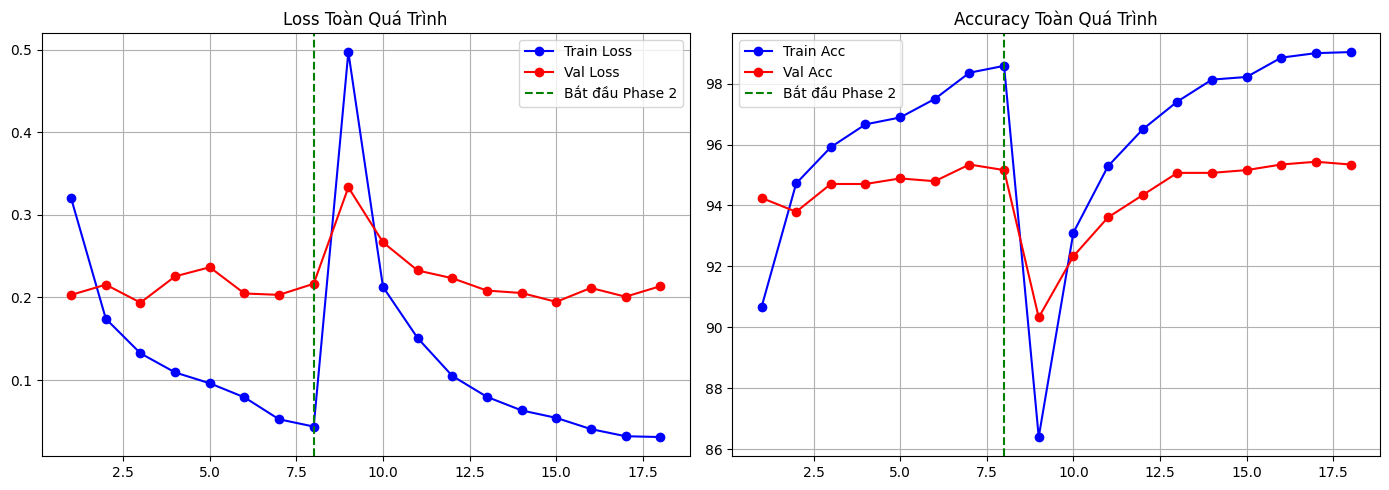

In [19]:
def plot_two_phases(h1, h2):
    lt = h1['train_loss'] + h2['train_loss']
    lv = h1['val_loss']   + h2['val_loss']
    at = h1['train_acc']  + h2['train_acc']
    av = h1['val_acc']    + h2['val_acc']
    ep = range(1, len(lt) + 1)
    sp = len(h1['train_loss'])

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(ep, lt, 'b-o', label='Train Loss')
    ax1.plot(ep, lv, 'r-o', label='Val Loss')
    ax1.axvline(x=sp, color='green', linestyle='--', label='Bắt đầu Phase 2')
    ax1.set_title("Loss Toàn Quá Trình"); ax1.legend(); ax1.grid(True)

    ax2.plot(ep, [a*100 for a in at], 'b-o', label='Train Acc')
    ax2.plot(ep, [a*100 for a in av], 'r-o', label='Val Acc')
    ax2.axvline(x=sp, color='green', linestyle='--', label='Bắt đầu Phase 2')
    ax2.set_title("Accuracy Toàn Quá Trình"); ax2.legend(); ax2.grid(True)

    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, 'training_history.png'), bbox_inches='tight', dpi=100)
    plt.show()

print("\n" + "="*50)
print("TỔNG KẾT")
print(f"  Phase 1 Best Val Acc: {acc_p1*100:.2f}%")
print(f"  Phase 2 Best Val Acc: {acc_p2*100:.2f}%")
print("="*50)
plot_two_phases(hist_p1, hist_p2)